## Imports and config

In [6]:
import dotenv
dotenv.load_dotenv()

True

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path
from jinja2 import Environment, FileSystemLoader
from typing import Callable, List, Dict, Any, Optional, Iterable

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Global seaborn style
sns.set_theme(
    style="white",
    context="talk",   # good default for presentations & notebooks
    rc={"axes.spines.right": False, "axes.spines.top": False},
    font_scale=0.9
)

# Consistent palette (colorblind-friendly, professional)
PALETTE = "colorblind"
sns.set_palette(PALETTE)

# Matplotlib defaults for all plots
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

## Connect to db

In [8]:
from mapa_ciencia_unc.db import init_db

In [9]:
session = await init_db()

## Articles

In [13]:
from mapa_ciencia_unc.models.article import Article

async def list_articles():
    articles = await Article.find_all().to_list()
    return articles

In [14]:
all_articles = await list_articles()

In [112]:
# build dataframe
articles_df = pd.DataFrame([
    {"cuit": a.cuit, "title": a.titulo, "abstract": a.resumen}
    for a in all_articles
])
articles_df.head(1)[['title',  'abstract']]

,title,abstract
0,Ideologías contemporáneas en el discurso lingü...,n los últimos años el lenguaje no binario ha a...


<Figure size 500x1000 with 0 Axes>

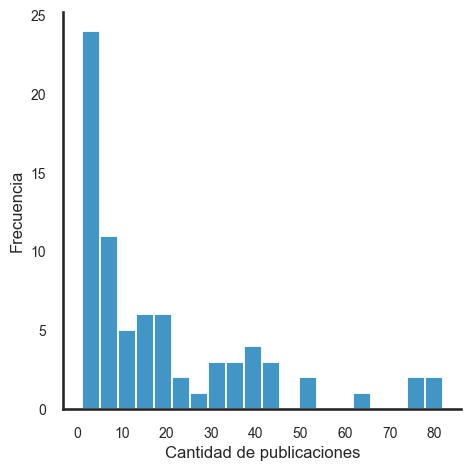

In [52]:
# count articles per cuit
counts = articles_df.value_counts("cuit").reset_index(name="num_articles")

# plot
plt.figure(figsize=(5, 10))
sns.displot(counts['num_articles'], bins=20)
plt.xlabel("Cantidad de publicaciones")
plt.ylabel("Frecuencia")
plt.show()

## Projects

In [33]:
from mapa_ciencia_unc.models.project import Project


async def list_projects():
    projects = await Project.find_all().to_list()
    return projects

In [35]:
all_projects = await list_projects()

In [113]:
# build dataframe
projects_df = pd.DataFrame([
    {"cuit": a.cuit, "title": a.titulo_proyecto, "abstract": a.resumen_proyecto, "keywords": a.palabrasclaves}
    for a in all_projects
])
projects_df.head(1)[['title', 'abstract', 'keywords']]

,title,abstract,keywords
0,IDENTIFICACIÓN DE LOS MECANISMOS DE LA INMUNID...,La inmunidad innata local juega un papel clave...,"[TRYPANOSOMA CRUZI, TEJIDO CARDÍACO, INMUNIDAD..."


<Figure size 500x1000 with 0 Axes>

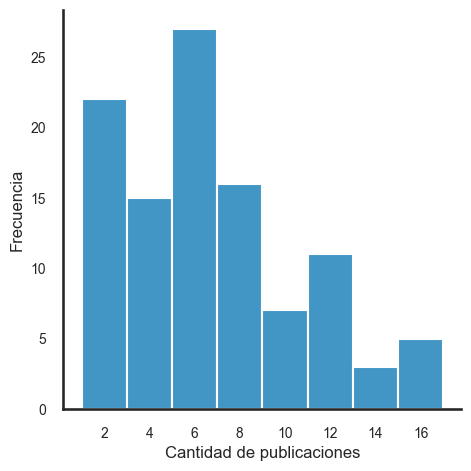

In [51]:
# count articles per cuit
counts = projects_df.value_counts("cuit").reset_index(name="num_projects")

# plot
plt.figure(figsize=(5, 10))
sns.displot(counts['num_projects'])
plt.xlabel("Cantidad de publicaciones")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Calls

## Portfolios

In [88]:
shared_dirpath = "/home/mteruel/toshare/pri"

In [59]:
import os

portfolios_filepath = os.path.join(shared_dirpath, "2_merged_sampled_data/portfolios.json")
portfolios_filepath

'/home/mteruel/toshare/pri/2_merged_sampled_data/portfolios.json'

In [74]:
portfolios_df = pd.read_json(portfolios_filepath, lines=True)
portfolios_df.shape

(8, 34)

In [114]:
questions = [c for c  in portfolios_df.columns if c not in ['cuit', 'email']]
portfolios_df["portfolio_text"] = portfolios_df[questions].apply(
    lambda row: "\n".join(
        f"{col}: {row[col]}" for col in questions if pd.notna(row[col])
    ),
    axis=1,
)
portfolios_df = portfolios_df[['cuit', 'portfolio_text']]
portfolios_df.head(1)[['portfolio_text']]

,portfolio_text
0,portfolio_text: activos_institucionales_unc: c...


## PDFs

In [92]:
pdfs_filepath = os.path.join(shared_dirpath, "all_intros.json")

In [95]:
import json
import pandas as pd

rows = []

with open(pdfs_filepath, "r", encoding="utf-8") as f:
    try:
        data = json.load(f)
    except json.JSONDecodeError as e:
        raise ValueError(f"Invalid JSON file: {e}")

for key, value in data.items():
    try:
        cuit = key.split("_", 1)[0]
        if not cuit.isdigit():
            continue  # skip malformed keys

        rows.append({
            "cuit": cuit,
            "text": str(value) if value is not None else ""
        })
    except Exception:
        continue  # be robust to unexpected formats

pdf_df = pd.DataFrame(rows)

In [111]:
pdf_df.head()[['text']]

,text
0,Determinación de la calidad y conservación de ...
1,Proyecto de Investigación | SECYT | UNC | Sub...
2,PROYECTO: Modificaciones de la composición min...
3,Mecanismos involucrados en la regulación de la...
4,"LA TRANSFORMACION DEL ESTADO NACION, EL CASO A..."


## Word counts

In [110]:
articles_df.head()[['title', 'abstract']]

,title,abstract
0,Ideologías contemporáneas en el discurso lingü...,n los últimos años el lenguaje no binario ha a...
1,Bucear sin agua: Experiencias desde el encierro,l taller de lectura y escritura Bucear sin agu...
2,La pre-consulta como estrategia de Enseñanza-A...,esde el 2012 se desarrolla en Córdoba una expe...
3,MOTIVOS DE CONSULTA PREVALENTES EN CENTROS DE ...,l objetivo es identificar y analizar los motiv...
4,Estrategias implementadas en el Hospital Nacio...,ntroducción: Declarada la Emergencia Sanitaria...


In [97]:
def words_per_cuit(df: pd.DataFrame, text_cols: list[str]) -> pd.Series:
    return (
        df.assign(
            _text=df[text_cols]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
        )
        .assign(_words=lambda x: x["_text"].str.split().str.len())
        .groupby("cuit")["_words"]
        .sum()
    )

# define text columns per dataframe
projects_words = words_per_cuit(projects_df, ["title", "abstract", "keywords"])
articles_words = words_per_cuit(articles_df, ["title", "abstract"])
portfolios_words = words_per_cuit(portfolios_df, ["portfolio_text"])
pdf_words = words_per_cuit(pdf_df, ["text"])

In [98]:
pdf_words.describe()

count     703.000000
mean     3060.227596
std      1766.072152
min       307.000000
25%      1923.000000
50%      2907.000000
75%      4000.000000
max      9164.000000
Name: _words, dtype: float64

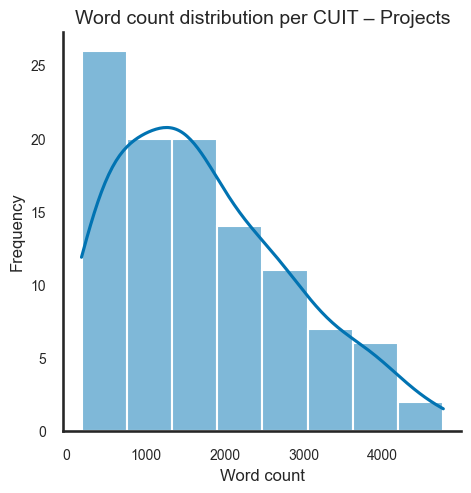

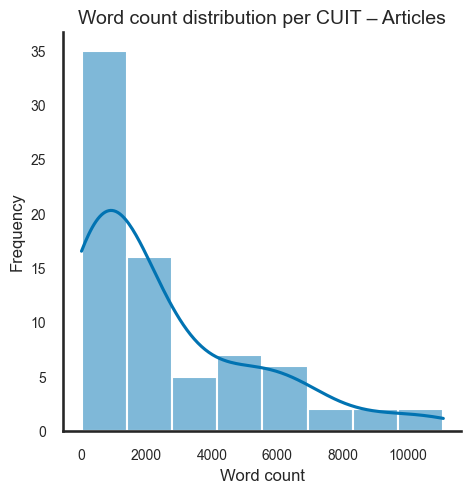

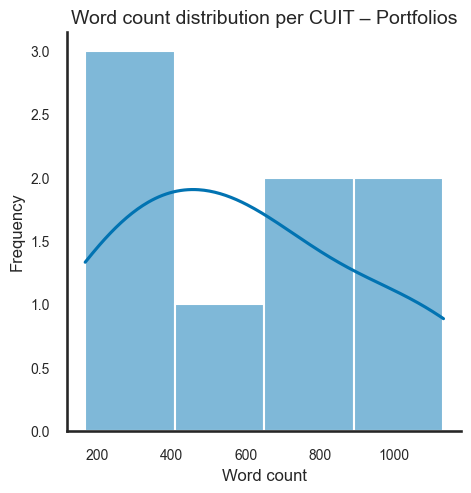

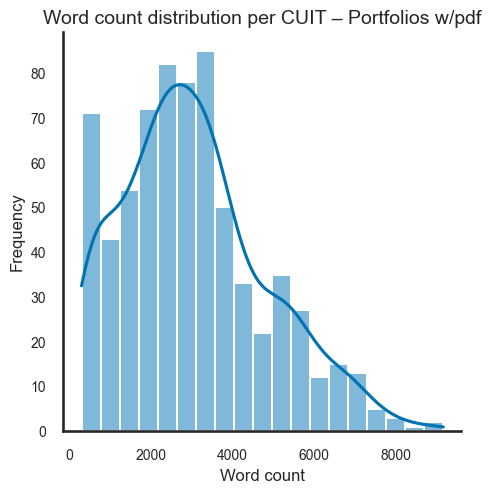

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# projects
sns.displot(projects_words, kde=True)
plt.title("Word count distribution per CUIT – Projects")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

# articles
sns.displot(articles_words, kde=True)
plt.title("Word count distribution per CUIT – Articles")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

# portfolios
sns.displot(portfolios_words, kde=True)
plt.title("Word count distribution per CUIT – Portfolios")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

sns.displot(pdf_words, kde=True)
plt.title("Word count distribution per CUIT – Portfolios w/pdf")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

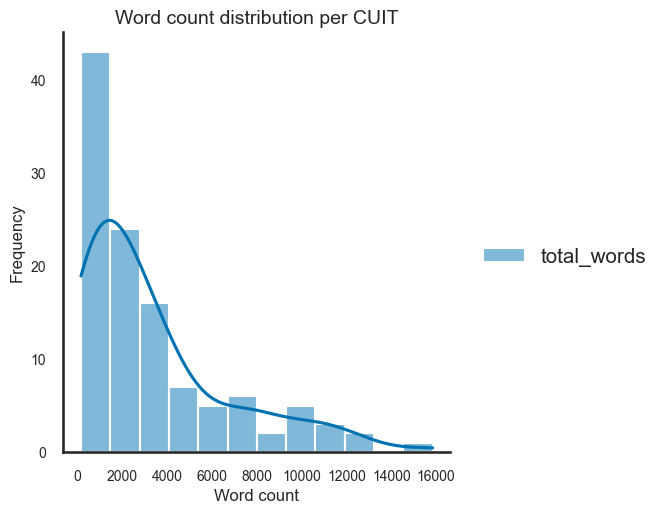

In [107]:
total_words_per_cuit = (
    pd.concat([projects_words, articles_words, portfolios_words])
    .groupby(level=0)
    .sum()
    .reset_index(name="total_words")
)
sns.displot(total_words_per_cuit, kde=True)
plt.title("Word count distribution per CUIT")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

In [105]:
total_words_per_cuit_w_pdf = (
    pd.concat([projects_words, articles_words, portfolios_words, pdf_words])
    .groupby(level=0)
    .sum()
    .reset_index(name="total_words")
)

In [108]:
total_words_per_cuit_w_pdf.describe()

,total_words
count,711.000000
mean,3566.395218
std,2785.046438
min,167.000000
25%,1992.500000
50%,3000.000000
75%,4497.000000
max,24044.000000


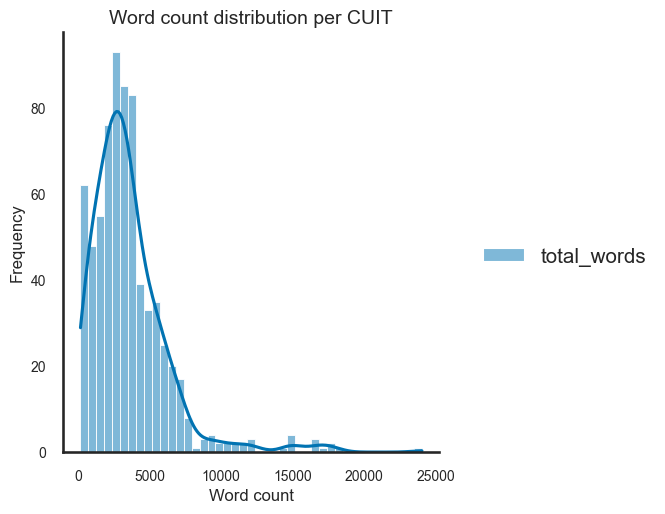

In [106]:
sns.displot(total_words_per_cuit_w_pdf, kde=True)
plt.title("Word count distribution per CUIT")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

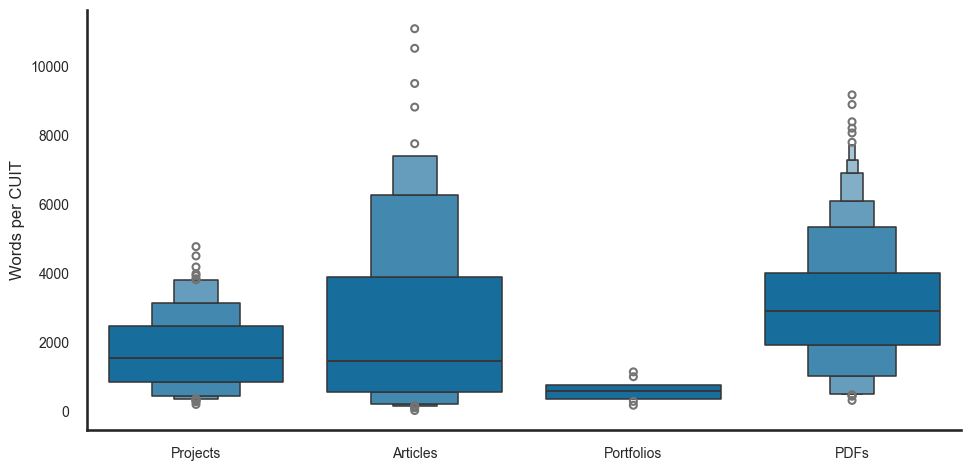

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# combine into one dataframe
plot_df = pd.concat(
    [
        projects_words.rename("words").to_frame().assign(source="Projects"),
        articles_words.rename("words").to_frame().assign(source="Articles"),
        portfolios_words.rename("words").to_frame().assign(source="Portfolios"),
        pdf_words.rename("words").to_frame().assign(source="PDFs"),
    ],
    ignore_index=True,
)

# plot
plt.figure(figsize=(10, 5))
sns.boxenplot(data=plot_df, x="source", y="words")
plt.xlabel("")
plt.ylabel("Words per CUIT")
plt.tight_layout()
plt.show()